# Phase 2 — Exploratory Data Analysis

## Uncertainty-Aware Material Selection using Machine Learning

### Objective
Explore the cleaned materials dataset to understand feature distributions,
target behavior, potential outliers, and relationships between variables
before preprocessing and modeling.

### Target
- `K_VRH`: Voigt-Reuss-Hill bulk modulus

### Features
- `nsites`
- `volume`
- `space_group`
- `elastic_anisotropy`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/clean_materials_data.csv")

df.head()

,nsites,volume,space_group,elastic_anisotropy,K_VRH
0,12,194.419802,124,0.030688,194.268884
1,5,61.987320,164,0.266910,175.449907
2,2,25.952539,221,0.756489,295.077545
3,4,76.721433,63,2.376805,49.130670
4,12,160.300999,62,0.196930,256.768081


In [2]:
df.shape

(1181, 5)

## 1. Descriptive Statistics

Before visualizing the data, we examine the basic statistical properties of the target and input features.

In [3]:
df.describe()

,nsites,volume,space_group,elastic_anisotropy,K_VRH
count,1181.000000,1181.000000,1181.000000,1181.000000,1181.000000
mean,12.425910,207.177098,163.403895,2.145013,136.259661
std,11.817997,192.355747,65.040733,19.140097,72.886978
min,2.000000,15.850527,4.000000,0.000005,6.476135
25%,5.000000,83.944059,124.000000,0.145030,76.435350
50%,10.000000,168.920404,193.000000,0.355287,130.382766
75%,16.000000,261.420345,221.000000,0.923117,189.574194
max,152.000000,2398.906164,229.000000,397.297866,435.661487


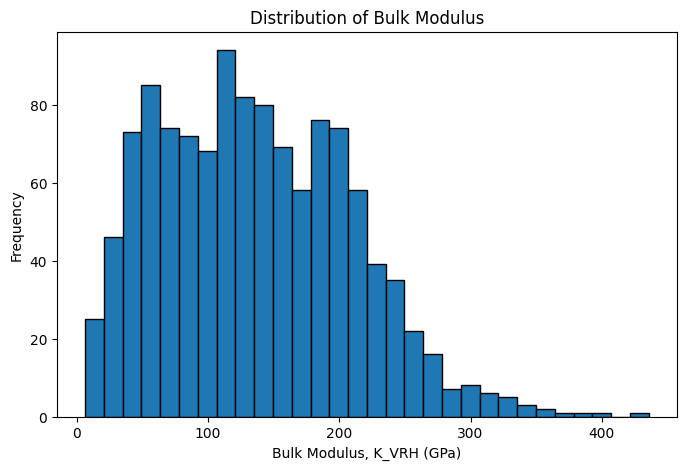

In [4]:
plt.figure(figsize=(8, 5))

plt.hist(df["K_VRH"], bins=30, edgecolor="black")

plt.xlabel("Bulk Modulus, K_VRH (GPa)")
plt.ylabel("Frequency")
plt.title("Distribution of Bulk Modulus")

plt.show()

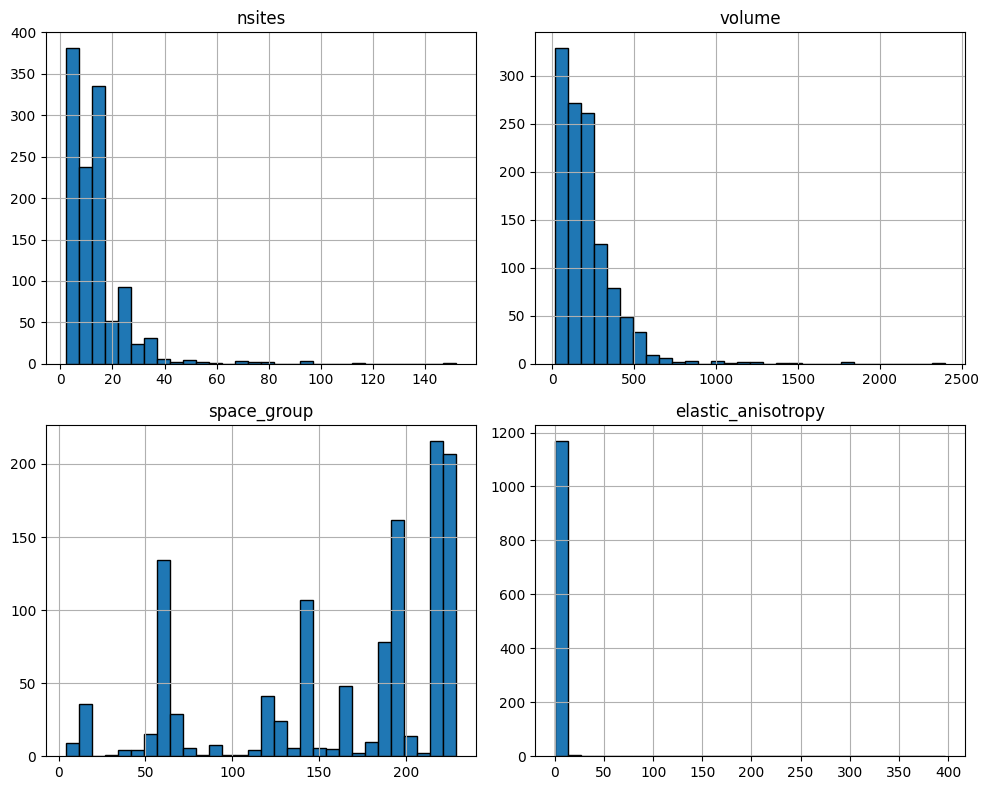

In [5]:
feature_cols = [
    "nsites",
    "volume",
    "space_group",
    "elastic_anisotropy"
]

df[feature_cols].hist(
    bins=30,
    figsize=(10, 8),
    edgecolor="black"
)

plt.tight_layout()
plt.show()

In [6]:
df["elastic_anisotropy"].quantile([
    0.50,
    0.75,
    0.90,
    0.95,
    0.99,
    1.00
])

0.50      0.355287
0.75      0.923117
0.90      2.309205
0.95      3.924760
0.99     12.298477
1.00    397.297866
Name: elastic_anisotropy, dtype: float64

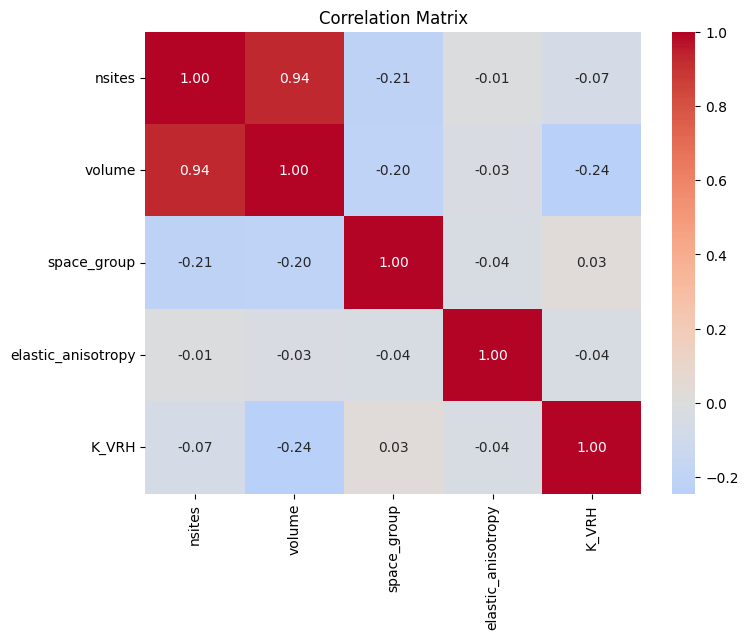

In [7]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

## EDA Summary

- The dataset contains 1,181 materials and four selected input features.
- `K_VRH` (bulk modulus) is the target variable and exhibits a moderately
  right-skewed distribution, with relatively few materials having very high
  bulk modulus values.
- `nsites` and `volume` are right-skewed and strongly correlated
  (Pearson r ≈ 0.94), indicating substantial redundancy between these
  structural descriptors.
- `elastic_anisotropy` is extremely right-skewed. Approximately 99% of
  observations are below 12.3, while the maximum is approximately 397.3.
  These extreme observations require further investigation rather than
  automatic removal.
- `volume` has the strongest observed linear association with `K_VRH`
  (r ≈ -0.24), although the relationship is weak.
- The remaining features show weak Pearson correlations with the target.
  This does not rule out nonlinear relationships.
- `space_group` represents crystallographic symmetry classes and should not
  be interpreted as a continuous numerical magnitude.
- No transformations or outlier removal were performed during EDA.
  Preprocessing decisions will be made in the next phase while avoiding
  data leakage.